# 09 — QQ Rounds Ablation: Does Query-to-Query Smoothing Help?

Compares three configurations that isolate the effect of QQ (query-to-query) message passing
in Stage 3 of the AttentionESPN model.  All runs use both batching strategies
(protein-weighted MSE + gradient accumulation).

| Suffix | Features | n_qq_rounds | Notes |
|---|---|---|---|
| `both_batching` | curvature + normals + multi-agg | 2 | Full model baseline |
| `both_batching_no_qq` | curvature + normals + multi-agg | 0 | Remove QQ smoothing |
| `multi_batching_no_qq` | multi-agg only | 0 | No geometry features, no QQ |

If `both_batching_no_qq` matches `both_batching`, QQ rounds add no useful information
and may be over-smoothing the query surface.  Comparing against `multi_batching_no_qq`
shows whether geometry features (curvature + normals) still matter without QQ.

**Sections:**
1. Configuration
2. Training curves
3. Error distributions
4. Metrics comparison

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


def show_png_grid(runs, filename, title, ncols=2):
    """Display saved PNG plots from each run's plot_dir in a grid."""
    available = [r for r in runs if (r["plot_dir"] / filename).exists()]
    if not available:
        print(f"No '{filename}' plots found. Run analyze_model.py --save-plots first.")
        return
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows))
    axes = axes.flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(title, fontsize=14, fontweight="bold", y=1.01)
    for ax, run in zip(axes, available):
        ax.imshow(mpimg.imread(run["plot_dir"] / filename))
        ax.set_title(run["label"], fontsize=11)
        ax.axis("off")
    for ax in axes[len(available):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_metric_bars(df, title):
    """Single-panel grouped bar chart for QQ ablation runs."""
    if df.empty:
        print("No data to plot.")
        return
    metrics = [("Pearson r", "steelblue"), ("RMSE", "darkorange"), ("MAE", "seagreen")]
    n_metrics   = len(metrics)
    total_width = 0.7
    bar_w       = total_width / n_metrics
    fig, ax = plt.subplots(figsize=(9, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")
    x = range(len(df))
    for i, (metric, color) in enumerate(metrics):
        if metric not in df.columns or df[metric].isna().all():
            continue
        offsets = [xi - total_width / 2 + bar_w * i + bar_w / 2 for xi in x]
        bars = ax.bar(offsets, df[metric], width=bar_w, color=color, label=metric, zorder=3)
        ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8, rotation=90)
    ax.set_xlabel("Configuration")
    ax.set_xticks(list(x))
    ax.set_xticklabels(df["Suffix"].tolist(), fontsize=9, rotation=15, ha="right")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

## 1. Configuration

In [3]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

QQ_RUNS = [
    dict(
        label   = "both_batching (qq=2, baseline)",
        suffix  = "both_batching",
        plot_dir = EVAL_ROOT / "attention_both_batching",
        ckpt_dir = CKPT_ROOT / "attention_both_batching",
    ),
    dict(
        label   = "both_batching_no_qq (qq=0, full features)",
        suffix  = "both_batching_no_qq",
        plot_dir = EVAL_ROOT / "attention_both_batching_no_qq",
        ckpt_dir = CKPT_ROOT / "attention_both_batching_no_qq",
    ),
    dict(
        label   = "multi_batching_no_qq (qq=0, no geometry)",
        suffix  = "multi_batching_no_qq",
        plot_dir = EVAL_ROOT / "attention_multi_batching_no_qq",
        ckpt_dir = CKPT_ROOT / "attention_multi_batching_no_qq",
    ),
]

print(f"{'Run':<45}  {'Plots':>6}  {'Metrics':>8}")
print("-" * 65)
for r in QQ_RUNS:
    has_plots   = r["plot_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    print(f"{r['label']:<45}  {'yes' if has_plots else 'no':>6}  {'yes' if has_metrics else 'no':>8}")

Run                                             Plots   Metrics
-----------------------------------------------------------------
both_batching (qq=2, baseline)                    yes       yes
both_batching_no_qq (qq=0, full features)         yes       yes
multi_batching_no_qq (qq=0, no geometry)          yes       yes


## 2. Training Curves

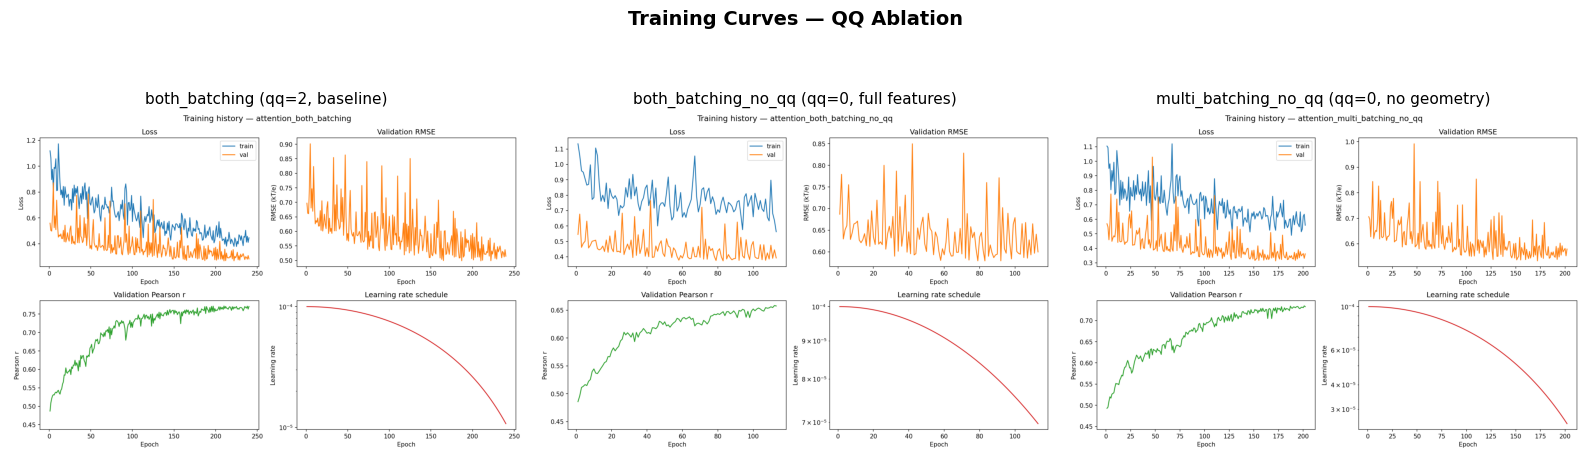

In [4]:
show_png_grid(QQ_RUNS, "training_curves.png", "Training Curves — QQ Ablation", ncols=3)

## 3. Error Distributions

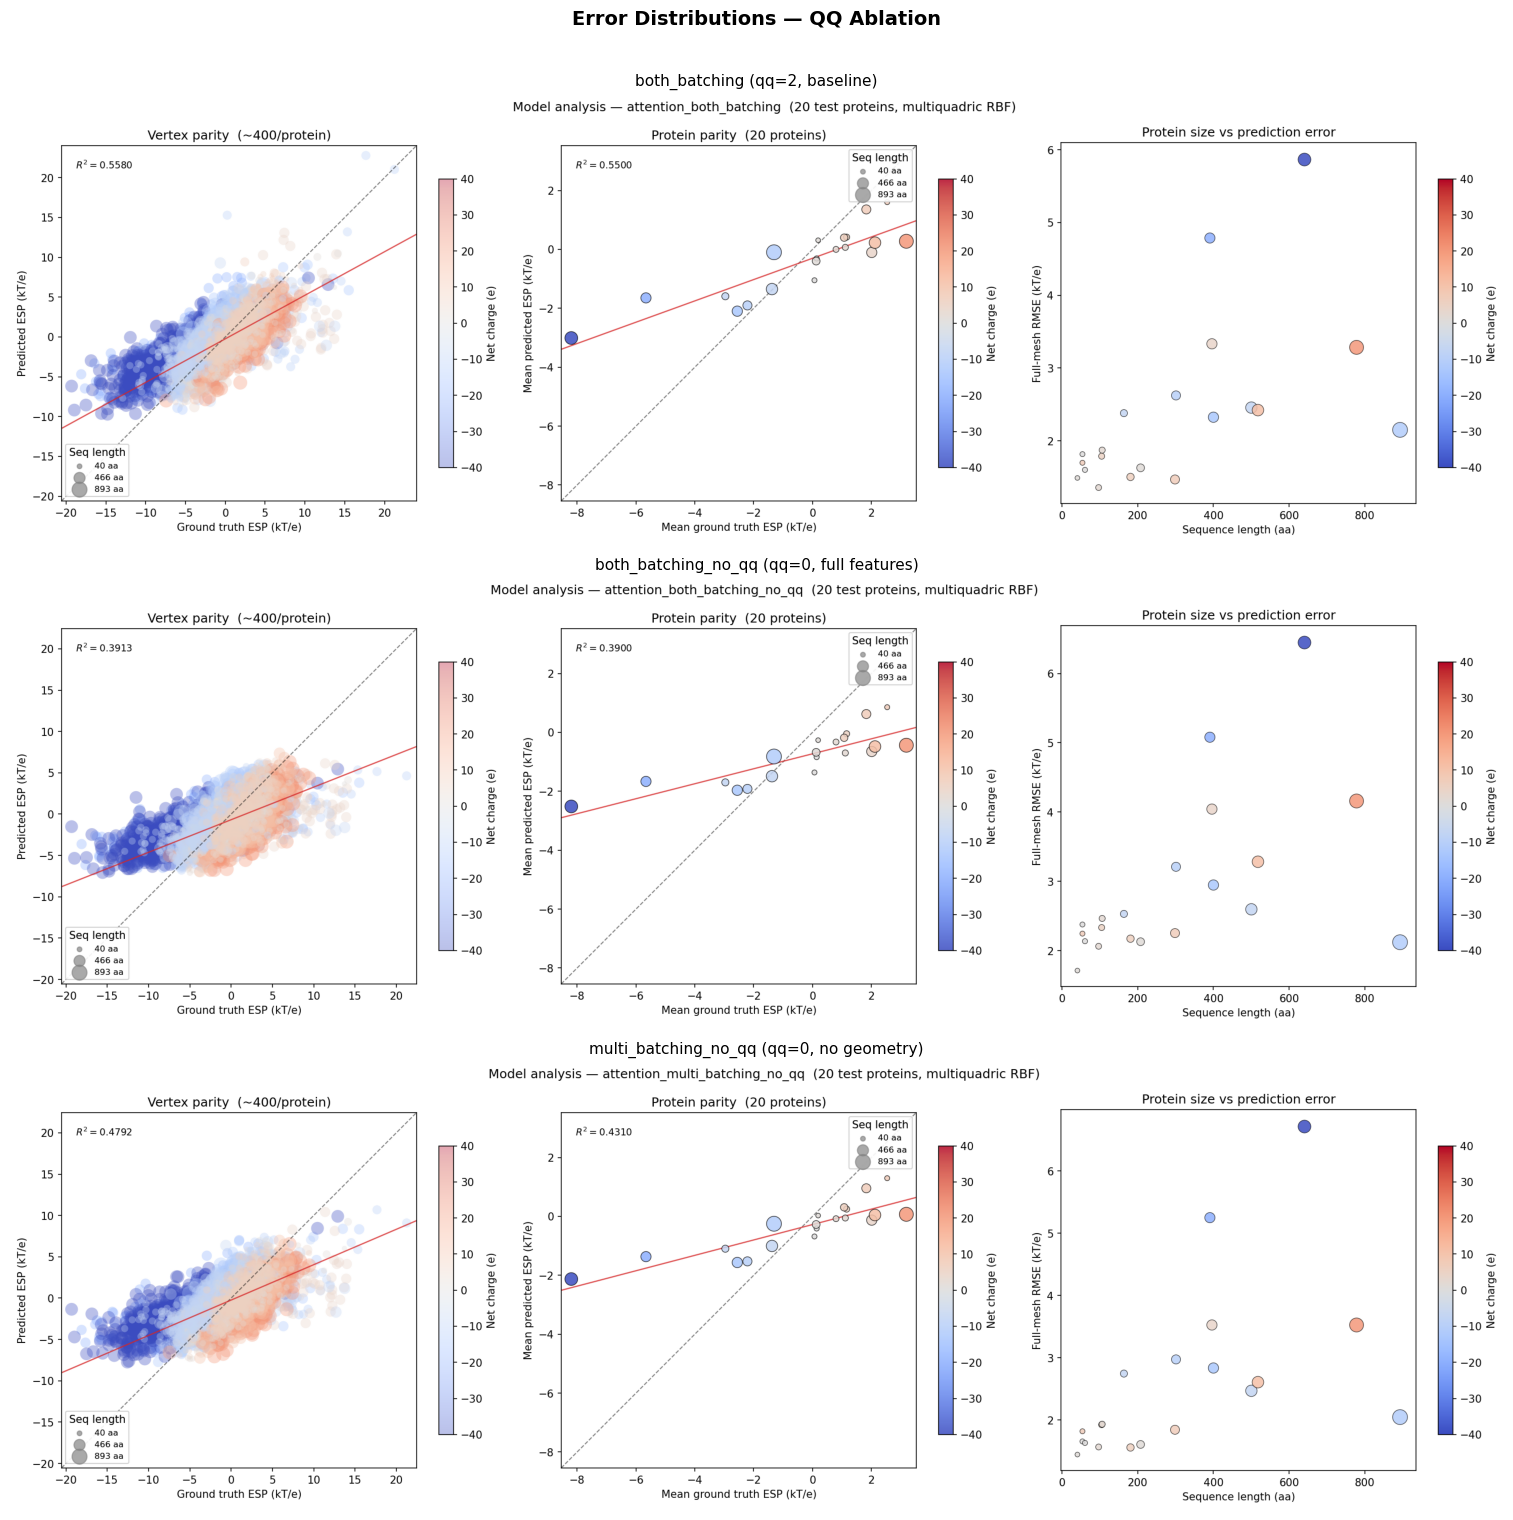

In [5]:
show_png_grid(QQ_RUNS, "error_distributions.png", "Error Distributions — QQ Ablation", ncols=1)

## 4. Metrics Comparison

In [6]:
rows_qq = []
for run in QQ_RUNS:
    metrics_path = run["ckpt_dir"] / "test_metrics.json"
    if not metrics_path.exists():
        print(f"  {run['label']}: test_metrics.json not found — sweep may still be running.")
        continue
    with open(metrics_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq.append({
        "Run":            run["label"],
        "Suffix":         run["suffix"],
        "Pearson r":      g.get("pearson_r"),
        "RMSE":           g.get("rmse"),
        "MAE":            g.get("mae"),
        "Val loss":       g.get("loss"),
        "Train time (s)": g.get("train_wall_time_s"),
        "N proteins":     g.get("n_proteins"),
    })

df_qq = pd.DataFrame(rows_qq)
pd.set_option("display.float_format", "{:.4f}".format)
display(df_qq)

,Run,Suffix,Pearson r,RMSE,MAE,Val loss,Train time (s),N proteins
0,"both_batching (qq=2, baseline)",both_batching,0.7831,2.9417,2.2233,0.3575,2004.3000,20
1,"both_batching_no_qq (qq=0, full features)",both_batching_no_qq,0.6674,3.4296,2.6114,0.4977,876.1000,20
2,"multi_batching_no_qq (qq=0, no geometry)",multi_batching_no_qq,0.7479,3.1925,2.3830,0.4226,1540.7000,20


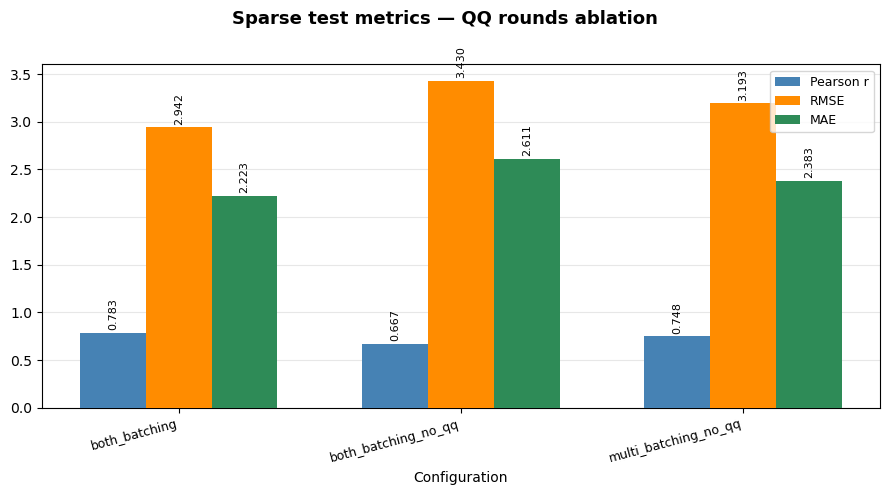

In [7]:
plot_metric_bars(df_qq, "Sparse test metrics — QQ rounds ablation")

### Full-mesh metrics

,Run,Suffix,Pearson r,RMSE,MAE,N proteins
0,"both_batching (qq=2, baseline)",both_batching,0.7815,2.9499,2.2420,20
1,"both_batching_no_qq (qq=0, full features)",both_batching_no_qq,0.6678,3.4596,2.6518,20
2,"multi_batching_no_qq (qq=0, no geometry)",multi_batching_no_qq,0.7483,3.2124,2.4142,20


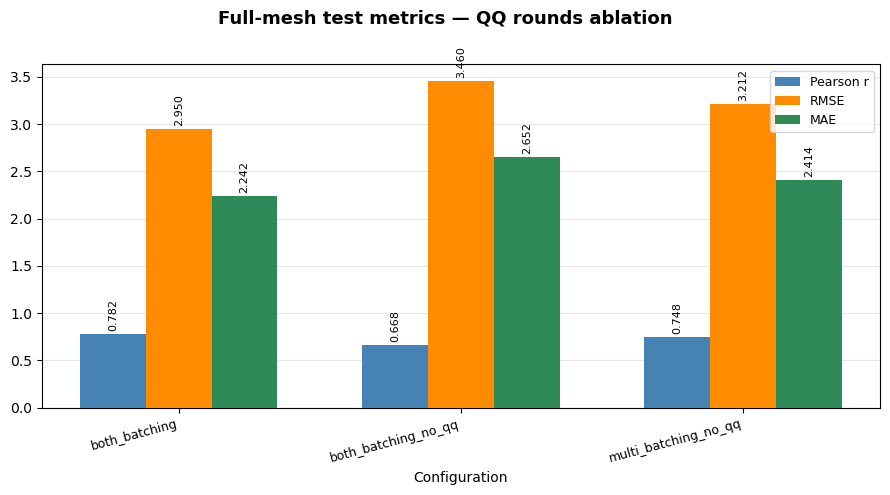

In [8]:
rows_qq_fm = []
for run in QQ_RUNS:
    fm_path = run["ckpt_dir"] / "test_metrics_fullmesh.json"
    if not fm_path.exists():
        continue
    with open(fm_path) as f:
        data = json.load(f)
    g = data.get("global", {})
    rows_qq_fm.append({
        "Run":        run["label"],
        "Suffix":     run["suffix"],
        "Pearson r":  g.get("pearson_r"),
        "RMSE":       g.get("rmse"),
        "MAE":        g.get("mae"),
        "N proteins": g.get("n_proteins"),
    })

if rows_qq_fm:
    df_qq_fm = pd.DataFrame(rows_qq_fm)
    display(df_qq_fm)
    plot_metric_bars(df_qq_fm, "Full-mesh test metrics — QQ rounds ablation")
else:
    print("No full-mesh metrics found yet.")

## 5. 3D Visualisation

Loads predictions for all three QQ configurations and renders a **3 × 3 grid**:
one row per model × three columns (Prediction | Ground Truth | |Pred − GT|) for one protein.
Shows how QQ smoothing affects the predicted ESP surface relative to ground truth.

In [10]:
import io
import os

import numpy as np
import pyvista as pv
import PIL.Image
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from IPython.display import display as ipy_display, Image as ipy_Image

os.environ.setdefault("DISPLAY", ":0")
os.environ.setdefault("WAYLAND_DISPLAY", "wayland-0")
os.environ.setdefault("XDG_RUNTIME_DIR", "/mnt/wslg/runtime-dir")
pv.set_jupyter_backend("static")

# ── Configuration ──────────────────────────────────────────────────────────────
EVAL_ROOT_VIZ = Path("/home/skyle/external_protein_data/model_eval")
DATA_ROOT_VIZ = Path("/home/skyle/external_protein_data")

VIZ_PID_QQ = "AF-Q6P2D8-5-F1"   # protein to visualise

CLIM_ESP = (-5, 5)
ERR_CLIM = (0, 5)
COLORMAP = "RdBu_r"
ERR_CMAP = "hot_r"
CAMERA   = "iso"
ZOOM     = 1.5           # >1 zooms in for static renders; adjust to taste

VIZ_QQ_RUNS = [
    dict(label="qq=2  (both_batching)",        run="attention_both_batching"),
    dict(label="qq=0  (both, no QQ)",          run="attention_both_batching_no_qq"),
    dict(label="qq=0  (multi, no QQ/geom)",    run="attention_multi_batching_no_qq"),
]

# ── Load full mesh + ground truth ──────────────────────────────────────────────
pid    = VIZ_PID_QQ
mesh_d = np.load(DATA_ROOT_VIZ / pid / "mesh" / f"{pid}_pqr_mesh.npz")
esp_d  = np.load(DATA_ROOT_VIZ / pid / "esp"  / f"{pid}_pqr_mesh_interp.npz")
verts_q  = mesh_d["verts"]
faces_q  = mesh_d["faces"]
esp_gt_q = esp_d["esp_verts"]

print(f"{pid}  —  {len(verts_q):,} verts  GT range [{esp_gt_q.min():.2f}, {esp_gt_q.max():.2f}]")

# ── Load sparse predictions → NN-fill to full mesh ────────────────────────────
def make_surf_q(scalar, name):
    pad   = np.full((len(faces_q), 1), 3, dtype=int)
    cells = np.hstack([pad, faces_q]).ravel()
    surf  = pv.PolyData(verts_q, cells)
    surf[name] = scalar
    return surf

for r in VIZ_QQ_RUNS:
    pred_path = EVAL_ROOT_VIZ / r["run"] / "test_predictions" / f"{pid}_pred.npz"
    if not pred_path.exists():
        print(f"  {r['label']:35s}  MISSING — skipped")
        continue
    d = np.load(pred_path)
    _, idx = cKDTree(d["query_pos"]).query(verts_q, workers=-1)
    pred = d["pred_esp"][idx].astype(np.float32)
    r["pred"]      = pred
    r["pearson_r"] = pearsonr(esp_gt_q.astype(float), pred.astype(float))[0]
    r["rmse"]      = float(np.sqrt(np.mean((pred - esp_gt_q) ** 2)))
    print(f"  {r['label']:35s}  r={r['pearson_r']:.4f}  rmse={r['rmse']:.4f}")

runs_qq = [r for r in VIZ_QQ_RUNS if "pred" in r]

AF-Q6P2D8-5-F1  —  115,486 verts  GT range [-7.56, 17.66]
  qq=2  (both_batching)                r=0.7762  rmse=2.4817
  qq=0  (both, no QQ)                  r=0.6612  rmse=3.2831
  qq=0  (multi, no QQ/geom)            r=0.7342  rmse=2.6554


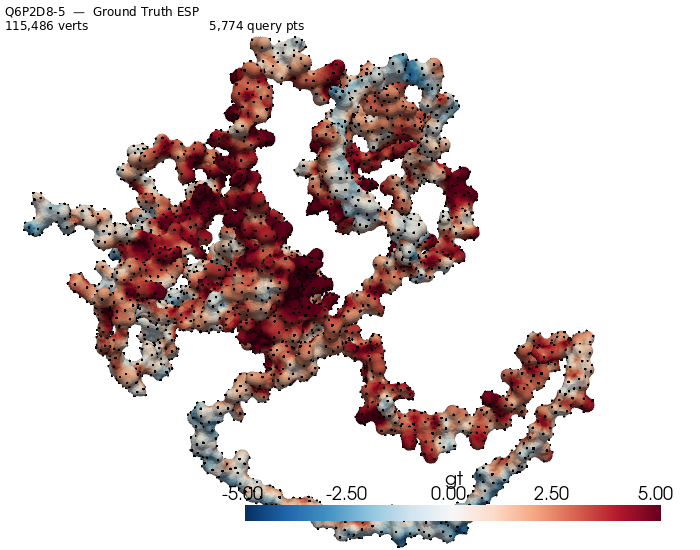

In [11]:
# ── Ground truth + query vertices — overview (static) ─────────────────────────
# Query positions are the same across all QQ runs for this protein.
qpos_qq = np.load(
    EVAL_ROOT_VIZ / runs_qq[0]["run"] / "test_predictions" / f"{pid}_pred.npz"
)["query_pos"]

short = pid.removeprefix("AF-").removesuffix("-F1")

pl = pv.Plotter(window_size=(700, 550), off_screen=True)
pl.set_background("white")
pl.add_mesh(make_surf_q(esp_gt_q, "gt"),
            scalars="gt", cmap=COLORMAP, clim=CLIM_ESP, show_scalar_bar=True)
pl.add_points(qpos_qq, color="black", point_size=3, render_points_as_spheres=True)
pl.add_text(
    f"{short}  —  Ground Truth ESP\n{len(verts_q):,} verts  |  {len(qpos_qq):,} query pts",
    font_size=9, color="black",
)
pl.camera_position = CAMERA
pl.camera.zoom(ZOOM)

img = pl.screenshot(return_img=True)
pl.close()

buf = io.BytesIO()
PIL.Image.fromarray(img).save(buf, format="PNG")
ipy_display(ipy_Image(data=buf.getvalue(), format="png"))

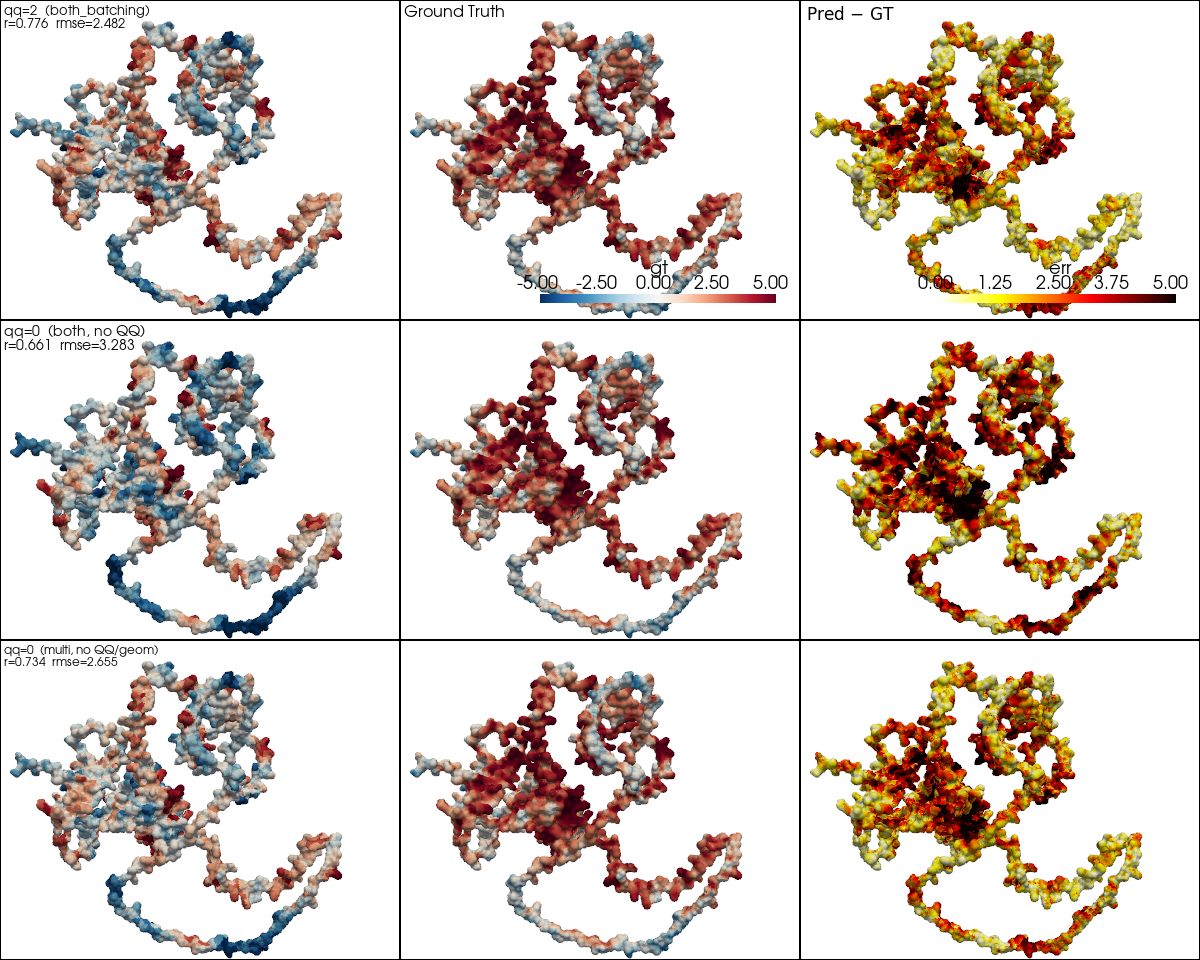

In [12]:
# ── 3×3 grid: three QQ models × (Prediction | Ground Truth | |Pred − GT|) ─────
n_rows = len(runs_qq)

pl = pv.Plotter(shape=(n_rows, 3), window_size=(1200, 320 * n_rows), off_screen=True)
pl.set_background("white")

for row, r in enumerate(runs_qq):
    err = np.abs(r["pred"] - esp_gt_q)

    pl.subplot(row, 0)
    pl.add_mesh(make_surf_q(r["pred"], "pred"),
                scalars="pred", cmap=COLORMAP, clim=CLIM_ESP, show_scalar_bar=False)
    pl.add_text(f"{r['label']}\nr={r['pearson_r']:.3f}  rmse={r['rmse']:.3f}",
                font_size=8, color="black")
    pl.camera_position = CAMERA
    pl.camera.zoom(ZOOM)

    pl.subplot(row, 1)
    pl.add_mesh(make_surf_q(esp_gt_q, "gt"),
                scalars="gt", cmap=COLORMAP, clim=CLIM_ESP, show_scalar_bar=(row == 0))
    if row == 0:
        pl.add_text("Ground Truth", font_size=8, color="black")
    pl.camera_position = CAMERA
    pl.camera.zoom(ZOOM)

    pl.subplot(row, 2)
    pl.add_mesh(make_surf_q(err, "err"),
                scalars="err", cmap=ERR_CMAP, clim=ERR_CLIM, show_scalar_bar=(row == 0))
    if row == 0:
        pl.add_text("|Pred − GT|", font_size=8, color="black")
    pl.camera_position = CAMERA
    pl.camera.zoom(ZOOM)

img = pl.screenshot(return_img=True)
pl.close()

buf = io.BytesIO()
PIL.Image.fromarray(img).save(buf, format="PNG")
ipy_display(ipy_Image(data=buf.getvalue(), format="png"))

In [13]:
# ── Interactive window (terminal) — linked views ──────────────────────────────
import pickle, subprocess, textwrap, tempfile

_data = {
    "verts": verts_q, "faces": faces_q, "esp_gt": esp_gt_q,
    "runs": [{"label": r["label"], "pred": r["pred"],
              "pearson_r": r["pearson_r"], "rmse": r["rmse"]}
             for r in runs_qq],
    "CLIM_ESP": CLIM_ESP, "ERR_CLIM": ERR_CLIM,
    "COLORMAP": COLORMAP, "ERR_CMAP": ERR_CMAP,
    "CAMERA": CAMERA, "pid": pid,
}
_pkl = tempfile.NamedTemporaryFile(suffix=".pkl", delete=False)
pickle.dump(_data, open(_pkl.name, "wb"))

_script = textwrap.dedent(f"""
    import pickle, numpy as np, pyvista as pv
    d = pickle.load(open({repr(_pkl.name)}, 'rb'))
    verts, faces, esp_gt = d['verts'], d['faces'], d['esp_gt']
    runs = d['runs']
    CLIM_ESP, ERR_CLIM = d['CLIM_ESP'], d['ERR_CLIM']
    COLORMAP, ERR_CMAP, CAMERA = d['COLORMAP'], d['ERR_CMAP'], d['CAMERA']
    pid = d['pid']

    def make_surf(s, name):
        pad = np.full((len(faces), 1), 3, dtype=int)
        cells = np.hstack([pad, faces]).ravel()
        m = pv.PolyData(verts, cells); m[name] = s; return m

    n_rows = len(runs)
    pl = pv.Plotter(shape=(n_rows, 3), window_size=(1200, 320 * n_rows))
    pl.set_background('white')

    for row, r in enumerate(runs):
        err = np.abs(r['pred'] - esp_gt)

        pl.subplot(row, 0)
        pl.add_mesh(make_surf(r['pred'], 'pred'),
                    scalars='pred', cmap=COLORMAP, clim=CLIM_ESP, show_scalar_bar=False)
        pl.add_text(f"{{r['label']}}\\nr={{r['pearson_r']:.3f}}  rmse={{r['rmse']:.3f}}",
                    font_size=8, color='black')
        pl.camera_position = CAMERA

        pl.subplot(row, 1)
        pl.add_mesh(make_surf(esp_gt, 'gt'),
                    scalars='gt', cmap=COLORMAP, clim=CLIM_ESP, show_scalar_bar=(row == 0))
        if row == 0:
            pl.add_text('Ground Truth', font_size=8, color='black')
        pl.camera_position = CAMERA

        pl.subplot(row, 2)
        pl.add_mesh(make_surf(err, 'err'),
                    scalars='err', cmap=ERR_CMAP, clim=ERR_CLIM, show_scalar_bar=(row == 0))
        if row == 0:
            pl.add_text('|Pred - GT|', font_size=8, color='black')
        pl.camera_position = CAMERA

    pl.link_views()
    pl.show(title=f'{{pid}} — QQ Ablation  (3×3)')
""")
_script_file = tempfile.NamedTemporaryFile(suffix=".py", delete=False, mode="w")
_script_file.write(_script); _script_file.close()

subprocess.Popen(
    ["bash", "-c", f"DISPLAY=:0 conda run -n protein_esp python {_script_file.name}"]
)
print("Launched interactive window in terminal.")

Launched interactive window in terminal.
